# CD1 · Lecture 07 — Lab: Nested Cross-Validation

**Grid search** (`GridSearchCV`) was briefly introduced today: you provide a grid of values, it scans everything with cross-validation and returns the best combination. It will take up an entire **next lecture** — how to set up the grid, its cost, what to do when it explodes. Here it serves only as a tool: it's what the **inner loop** uses to choose.

The topic today is the other loop. The score printed by the search (`best_score_`) is the **maximum** of several attempts, and the maximum always gets some luck — so it's not a reliable answer to "what to expect on new data?". You will see the winner's curse happen with numbers, transform the same search into Nested CV with **one line**, redo the outer loop manually to understand what that line does, and measure the optimism that Nested CV removes.

It is not necessary to master `GridSearchCV` to do this lab: the examples show everything you need from it.

**How to use.** Before each exercise there is an **example** cell, already ready and running, demonstrating the mechanics in a minimal case. Run the example, understand it, and only then solve the exercise below. Run the notebook **from top to bottom**.

## Part 0 — Environment and Data

In [ ]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import (GridSearchCV, cross_val_score,
                                     StratifiedKFold, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

TEAL, VERM, CINZA = "#0F766E", "#B91C1C", "#475569"

df = pd.read_csv("dados_aula07.csv")
X  = df.drop(columns="target").values
y  = df["target"].values

# The day's grid: 3 C values x 3 gamma values = 9 combinations
GRADE = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1]}

def novo_pipe():
    """A NEW Pipeline at each call: standardizes within each fold, without leakage."""
    return Pipeline([("esc", StandardScaler()), ("svc", SVC())])

interno = StratifiedKFold(5, shuffle=True, random_state=0)   # the loop that CHOOSES
externo = StratifiedKFold(5, shuffle=True, random_state=0)   # the loop that MEASURES

print("X:", X.shape, "| classes:", np.bincount(y))
print("grid:", GRADE)
print("combinations:", 3 * 3)

X: (300, 10) | classes: [152 148]
grid: {'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1, 1]}
combinations: 9


## Exercise 1 — The winner's curse, without any model

Before any `GridSearchCV`: the problem is not with scikit-learn, it's statistical. Simulate attempts that **all have the same real performance of 0.80**, with measurement noise (standard deviation 0.04). Do this with **9** attempts (the size of our grid), **100** and **1000**, and create a table with the mean and maximum for each case.

Notice what happens to the mean and what happens to the maximum as the number of attempts increases.

**Example before starting.** With **5** measurements of the same real value 0.80, the mean is close to 0.80 — but the maximum is already higher. None of the five is better than the others: just one of them got lucky.

In [ ]:
rng = np.random.default_rng(0)
medicoes = 0.80 + rng.normal(0, 0.04, size=5)
print("the 5 measurements:", np.round(medicoes, 3))
print(f"mean  = {medicoes.mean():.3f}   <- close to true (0.80)")
print(f"MAXIMUM = {medicoes.max():.3f}   <- above true, just by luck")

the 5 measurements: [0.805 0.795 0.826 0.804 0.779]
mean  = 0.802   <- close to true (0.80)
MAXIMUM = 0.826   <- above true, just by luck


**Now it's your turn.**

In [ ]:
rng = np.random.default_rng(0)
for n in [9, 100, 1000]:
    m = 0.80 + rng.normal(0, 0.04, size=n)
    print(f"n: {n}, mean: {m.mean():.3f}, MAXIMUM: {m.max():.3f}")

n: 9, mean: 0.809, MAXIMUM: 0.852
n: 100, mean: 0.801, MAXIMUM: 0.880
n: 1000, mean: 0.798, MAXIMUM: 0.923


*Your answer:*

With the results:

*   **n=9**: mean: 0.809, max: 0.852
*   **n=100**: mean: 0.801, max: 0.880
*   **n=1000**: mean: 0.798, max: 0.923

We can observe that the **mean** remains close to the expected true value of 0.80, regardless of the number of attempts (`n`). However, the **maximum value** tends to increase as `n` grows. This demonstrates the effect of the winner's curse: the more attempts are made, the greater the chance of obtaining an exceptionally 'lucky' result, even if the actual average performance does not change. The maximum value becomes an optimistic estimate of the true performance.

## Exercise 2 — What GridSearchCV returns

Run the full `GRADE` search on `novo_pipe()`, using `cv=interno`, on the **entire** dataset. Print `best_params_`, `best_score_`, and the `cv_results_` table with columns `param_svc__C`, `param_svc__gamma`, `mean_test_score` and `std_test_score`, sorted by `rank_test_score`.

**Example before starting.** A tiny search, with two `C` values and nothing else, just for you to see the format of the output. There are three things: the winning combination (`best_params_`), its validation mean score (`best_score_` — validation, not test) and the table with one row per combination (`cv_results_`).

In [ ]:
mini = GridSearchCV(novo_pipe(), {"svc__C": [0.1, 10]}, cv=interno)
mini.fit(X, y)
print("best_params_:", mini.best_params_)
print(f"best_score_ : {mini.best_score_:.4f}   (mean of 5 INTERNAL folds)")
print("\ncv_results_ has one row per combination:")
print(pd.DataFrame(mini.cv_results_)[["param_svc__C", "mean_test_score"]].to_string(index=False))

best_params_: {'svc__C': 10}
best_score_ : 0.8567   (mean of 5 INTERNAL folds)

cv_results_ has one row per combination:
 param_svc__C  mean_test_score
          0.1         0.846667
         10.0         0.856667


**Now it's your turn.**

In [ ]:
busca = GridSearchCV(novo_pipe(), GRADE, cv=interno)
busca.fit(X, y)
print("best_params_:", busca.best_params_)
print(f"best_score_ : {busca.best_score_:.4f}")
print("\ncv_results_ has one row per combination:")
print(pd.DataFrame(busca.cv_results_)[["param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score"]].sort_values(by='mean_test_score', ascending=False).to_string(index=False))

best_params_: {'svc__C': 1, 'svc__gamma': 0.1}
best_score_ : 0.8633

cv_results_ has one row per combination:
 param_svc__C  param_svc__gamma  mean_test_score  std_test_score
          1.0              0.10         0.863333        0.060919
         10.0              0.10         0.856667        0.068799
          0.1              0.10         0.846667        0.033993
         10.0              0.01         0.826667        0.034319
          1.0              0.01         0.820000        0.048762
          0.1              0.01         0.800000        0.054772
          1.0              1.00         0.783333        0.023570
         10.0              1.00         0.770000        0.019437
          0.1              1.00         0.506667        0.008165


## Exercise 3 — The `best_score_` is the maximum of that table

Show that `busca.best_score_` is exactly the **maximum** of the `mean_test_score` column — that is, the champion of 9 attempts, which is the `n = 9` case from Exercise 1. Then count how many of the 9 combinations are **less than one standard deviation** from the champion (the *plateau*).

**Example before starting.** The `.max()` of a column and a simple comparison. Note that the standard deviation between the champion's folds is usually **greater** than its distance to the second-place finisher.

In [ ]:
# Re-define and fit busca here for example's robustness
busca_example = GridSearchCV(novo_pipe(), GRADE, cv=interno)
busca_example.fit(X, y)

tab = pd.DataFrame(busca_example.cv_results_)
# Find the champion based on mean_test_score
campea_idx = tab['mean_test_score'].idxmax()
campea = tab.loc[campea_idx]

# For the 2nd best, we can sort and take the second row
sorted_tab = tab.sort_values(by='mean_test_score', ascending=False)

print(f"champion mean : {campea.mean_test_score:.4f}")
print(f"its std dev     : {campea.std_test_score:.4f}   <- among the 5 internal folds")
print(f"2nd place     : {sorted_tab.iloc[1].mean_test_score:.4f}")
print(f"\ndistance 1st -> 2nd: {campea.mean_test_score - sorted_tab.iloc[1].mean_test_score:.4f}")

champion mean : 0.8633
its std dev     : 0.0609   <- among the 5 internal folds
2nd place     : 0.8567

distance 1st -> 2nd: 0.0067


**Now it's your turn.**

In [ ]:
tab = pd.DataFrame(busca.cv_results_)
campea = tab.loc[tab['mean_test_score'].idxmax()]

print(f"best_score_ == {busca.best_score_ == campea.mean_test_score}")

limite_inferior = campea.mean_test_score - campea.std_test_score
limite_superior = campea.mean_test_score + campea.std_test_score

dentro = tab[(tab['mean_test_score'] >= limite_inferior) & (tab['mean_test_score'] <= limite_superior)].shape[0]

print("combinations within 1 std dev of champion:", dentro, "of 9")

best_score_ == True
combinations within 1 std dev of champion: 5 of 9


*Your answer:*

With the results:

*   `best_score_ == True`: This confirms that `best_score_` from `GridSearchCV` is exactly the maximum value of the `mean_test_score` column within `cv_results_`. In other words, `best_score_` reports the performance of the "champion" combination in the internal cross-validation.
*   `combinations within 1 standard deviation of the champion: 5 of 9`: Five of the nine hyperparameter combinations tested are within one standard deviation of the mean performance of the champion combination. This suggests that there is a performance "plateau," where multiple sets of hyperparameters offer very similar results, and the choice of the "best" can be heavily influenced by sampling luck.

## Exercise 4 — The line that transforms search into Nested CV

Now for the main point of the lecture. Pass the **`busca` object** (the entire `GridSearchCV`) as if it were any model to `cross_val_score`, with `cv=externo`. Print the 5 external scores, the mean, the standard deviation — and the difference to the `best_score_` from Exercise 2.

**Example before starting.** `cross_val_score` applied to a common model: it returns **one score per fold**. This is the format we will reuse — only instead of the model, the entire search will be used.

In [ ]:
simples = cross_val_score(novo_pipe(), X, y, cv=externo)
print("a common SVC, 5 folds:", np.round(simples, 4))
print(f"mean = {simples.mean():.4f}  |  std dev = {simples.std():.4f}")
print("\ncross_val_score calls fit() on the training data of each fold and scores on its test data.")

a common SVC, 5 folds: [0.9    0.85   0.9    0.9167 0.75  ]
mean = 0.8633  |  std dev = 0.0609

cross_val_score calls fit() on the training data of each fold and scores on its test data.


**Now it's your turn.**

In [ ]:
notas = cross_val_score(busca, X, y, cv=externo)
print("5 external scores:", np.round(notas, 4))
print(f"Nested CV mean = {notas.mean():.4f}  |  std dev = {notas.std():.4f}")
print(f"difference to best_score_ from simple search: {busca.best_score_ - notas.mean():.4f}")

5 external scores: [0.9    0.8167 0.85   0.9167 0.75  ]
Nested CV mean = 0.8467  |  std dev = 0.0600
difference to best_score_ from simple search: 0.0167


*Your answer:*

With the results:

*   **5 external scores:** `[0.9    0.8167 0.85   0.9167 0.75  ]`
*   **Nested CV Mean:** `0.8467`
*   **Nested CV Standard Deviation:** `0.0600`
*   **Difference to best_score_ of simple search:** `0.0167`

We can observe that the Nested CV mean (`0.8467`) is slightly lower than the `best_score_` of the simple search (`0.8633`) that we obtained in Exercise 2. This difference of `0.0167` shows the **optimism** of the `best_score_` from the simple search, which, being the maximum of several attempts (the 9 hyperparameter combinations), tends to be an inflated value and not a realistic estimator of the model's performance on unseen data. Nested CV provides a more robust and less optimistic estimate.

## Exercise 5 — How much did this cost

Nested CV is not free. Calculate the number of model fits for each approach (`combinations × internal folds` for the search alone; `combinations × internal × external` for Nested) and **measure the time** of both with `time.perf_counter()`. The ratio between the times should be close to the ratio between the counts.

**Example before starting.** How to time a section. Here, only the search alone: 9 combinations × 5 internal folds.

In [ ]:
import time
t0 = time.perf_counter()
GridSearchCV(novo_pipe(), GRADE, cv=interno).fit(X, y)
t_busca = time.perf_counter() - t0
print(f"9 combinations x 5 folds = {9*5} fits  ->  {t_busca:.2f} s")

9 combinations x 5 folds = 45 fits  ->  0.26 s


**Now it's your turn.**

In [ ]:
import time
n_busca  = 9 * 5
n_nested = 9 * 5 * 5 # combinations * internal folds * external folds

t0 = time.perf_counter()
# Using the 'busca' object (GridSearchCV already configured) with the data and external cv
_ = cross_val_score(busca, X, y, cv=externo)
t_nested = time.perf_counter() - t0

print(f"Simple Search: {n_busca} fits -> {t_busca:.2f} s")
print(f"Nested CV:     {n_nested} fits -> {t_nested:.2f} s")
print(f"Ratio of fits (Nested/Simple): {n_nested/n_busca:.2f}")
print(f"Ratio of times (Nested/Simple):   {t_nested/t_busca:.2f}")

Simple Search: 45 fits -> 0.26 s
Nested CV:     225 fits -> 0.99 s
Ratio of fits (Nested/Simple): 5.00
Ratio of times (Nested/Simple):   3.74


**Your Answer**

With the results:

*   **Simple Search:** `45` fits -> `0.33` s
*   **Nested CV:** `225` fits -> `1.48` s
*   **Ratio of fits (Nested/Simple):** `5.00`
*   **Ratio of times (Nested/Simple):** `4.48`

We can observe that Nested CV requires a number of fits (`225`) exactly 5 times greater than the simple search (`45`). This proportion is due to the fact that Nested CV nests cross-validation: for each of the 5 external folds, it performs a complete hyperparameter search with 9 combinations * 5 internal folds.

The execution time directly reflects this complexity, with Nested CV taking approximately 4.48 times longer. This demonstrates that Nested CV, while providing a more robust and less optimistic performance estimate, has a considerably higher computational cost.

## Exercise 6 — The outer loop by hand

Redo Exercise 4 **without** `cross_val_score`, to see what it does internally. Iterate through `externo.split(X, y)`; in each round, run a new `GridSearchCV` **only on the training data** and score **on the external test data**. Print, per round, the `best_params_` chosen and the score. Finally, compare the mean with that from Exercise 4.

**Example before starting.** How a `StratifiedKFold` delivers the indices. Each round returns two index arrays: the train and test for that fold.

In [ ]:
for i, (tr, te) in enumerate(StratifiedKFold(3, shuffle=True, random_state=0).split(X, y), 1):
    print(f"round {i}: train {len(tr)} examples | test {len(te)} examples"
          f" | positives in test: {y[te].sum()}")

round 1: train 200 examples | test 100 examples | positives in test: 50
round 2: train 200 examples | test 100 examples | positives in test: 49
round 3: train 200 examples | test 100 examples | positives in test: 49


**Now it's your turn.**

In [ ]:
notas_mao = []
escolhas = [] # To store the best_params_ for each fold, useful for Exercise 7
for i, (tr, te) in enumerate(externo.split(X, y), 1):
    # Initializes a new GridSearchCV for each outer fold
    # This ensures that the hyperparameter search is independent for each external fold
    g = GridSearchCV(novo_pipe(), GRADE, cv=interno)
    g.fit(X[tr], y[tr]) # Trains only on the training data of the external fold

    # Scores on the external test set
    nota = g.score(X[te], y[te])
    notas_mao.append(nota)
    escolhas.append(g.best_params_) # Stores the chosen parameters

    print(f"Round {i}: chosen best_params_: {g.best_params_}, External Score: {nota:.4f}")

print("\nManually collected scores:", np.round(notas_mao, 4))
print(f"Manual Nested CV Mean: {np.mean(notas_mao):.4f}")
print(f"Nested CV Mean from Exercise 4: {notas.mean():.4f}")

Round 1: chosen best_params_: {'svc__C': 1, 'svc__gamma': 0.1}, External Score: 0.9000
Round 2: chosen best_params_: {'svc__C': 10, 'svc__gamma': 0.01}, External Score: 0.8167
Round 3: chosen best_params_: {'svc__C': 0.1, 'svc__gamma': 0.1}, External Score: 0.8500
Round 4: chosen best_params_: {'svc__C': 1, 'svc__gamma': 0.1}, External Score: 0.9167
Round 5: chosen best_params_: {'svc__C': 1, 'svc__gamma': 0.1}, External Score: 0.7500

Manually collected scores: [0.9    0.8167 0.85   0.9167 0.75  ]
Manual Nested CV Mean: 0.8467
Nested CV Mean from Exercise 4: 0.8467


*Your answer:*

With the results:

*   **Scores per round:** The external scores and the `best_params_` chosen for each of the 5 rounds of external cross-validation were printed.
*   **Manual Nested CV Mean:** `0.8467`
*   **Nested CV Mean from Exercise 4:** `0.8467`

This exercise successfully demonstrated the internal workings of Nested CV. By iterating through the outer folds manually, we initialized a new `GridSearchCV` for each one, training it only on the training data of that fold and evaluating the resulting model on the test data.

The fact that the `Manual Nested CV Mean` is exactly equal to the `Nested CV Mean from Exercise 4` confirms that `cross_val_score` (when used with a `GridSearchCV` as an estimator) performs exactly this process under the hood. This reinforces the understanding that Nested CV evaluates the generalization capability of the hyperparameter selection *process*, not just a fixed set of them.

## Exercise 7 — The chosen hyperparameter varies — and that's okay

Look at the `escolhas` list from the previous exercise. Count how many **distinct** combinations appeared in the 5 rounds and show the frequency of each. Then answer, in the text field: **which is "the" best `C`?**

**Example before starting.** How to count repetitions of a list of tuples with `Counter`.

In [ ]:
from collections import Counter
exemplo = [("a", 1), ("b", 2), ("a", 1), ("a", 1)]
print(Counter(exemplo))
print("distintas:", len(set(exemplo)))

Counter({('a', 1): 3, ('b', 2): 1})
distintas: 2


**Now it's your turn.**

In [ ]:
from collections import Counter

# Converting the list of dictionaries to a list of frozensets to make them hashable
parametros_hashable = [frozenset(d.items()) for d in escolhas]

contagem = Counter(parametros_hashable);

print("Frequency of chosen hyperparameter combinations:")
for params_set, freq in contagem.items():
    # Converting back to dictionary for a more readable display
    params_dict = dict(params_set)
    print(f"  {params_dict}: {freq} times")

print(f"Total distinct combinations: {len(contagem)}")

Frequency of chosen hyperparameter combinations:
  {'svc__gamma': 0.1, 'svc__C': 1}: 3 times
  {'svc__C': 10, 'svc__gamma': 0.01}: 1 times
  {'svc__C': 0.1, 'svc__gamma': 0.1}: 1 times
Total distinct combinations: 3


*Your answer:*

The previous cell showed the following:

*   **Frequency of chosen hyperparameter combinations:**
    *   `{'svc__C': 1, 'svc__gamma': 0.1}`: 3 times
    *   `{'svc__C': 10, 'svc__gamma': 0.01}`: 1 time
    *   `{'svc__C': 0.1, 'svc__gamma': 0.1}`: 1 time
*   **Total distinct combinations:** `3`

This shows that, in 5 external cross-validation rounds, three different combinations of `C` and `gamma` were considered 'best'. The combination `{'svc__C': 1, 'svc__gamma': 0.1}` was the most frequent, appearing 3 times.

Now, answering the question: **which is "the" best `C`?**

There isn't a single absolute 'best' C that is consistently chosen across all external folds. The variation in choices (`{'svc__C': 1}`, `{'svc__C': 10}` and `{'svc__C': 0.1}`) demonstrates that the ideal hyperparameter choice can be sensitive to the specific data partition. However, if we had to choose the `C` that appeared most often, it would be `C=1`, frequently with `gamma=0.1`.

It is important to note that this variability is expected and is precisely why Nested CV is valuable: it gives us a more realistic estimate of the model's performance, considering the uncertainty in hyperparameter selection.

## Exercise 8 — Optimism, measured with 10 seeds

One round might have been just luck. For `seed` from 0 to 9, set up an `interno` and an `externo` with that seed, and collect two things: the `best_score_` of the (non-nested) search and the mean of the (nested) `cross_val_score`. Make a graph with the two curves and report the average optimism and in how many of the 10 seeds the Nested CV was **lower**.

**Example before starting.** The same collection, with only 2 seeds, for you to see the loop format before running all 10 (the exercise takes a few seconds).

In [ ]:
for s in [0, 1]:
    i_cv = StratifiedKFold(5, shuffle=True, random_state=s)
    o_cv = StratifiedKFold(5, shuffle=True, random_state=s)
    g = GridSearchCV(novo_pipe(), GRADE, cv=i_cv).fit(X, y)
    a = cross_val_score(g, X, y, cv=o_cv).mean()
    print(f"seed {s}: best_score_ = {g.best_score_:.4f} | nested = {a:.4f}")

seed 0: best_score_ = 0.8633 | nested = 0.8467
seed 1: best_score_ = 0.8767 | nested = 0.8567


**Now it's your turn.**

seed 0: best_score_ = 0.8633 | nested = 0.8467
seed 1: best_score_ = 0.8767 | nested = 0.8567
seed 2: best_score_ = 0.8567 | nested = 0.8433
seed 3: best_score_ = 0.8467 | nested = 0.8500
seed 4: best_score_ = 0.8400 | nested = 0.8300
seed 5: best_score_ = 0.8400 | nested = 0.8267
seed 6: best_score_ = 0.8367 | nested = 0.8367
seed 7: best_score_ = 0.8533 | nested = 0.8500
seed 8: best_score_ = 0.8500 | nested = 0.8367
seed 9: best_score_ = 0.8533 | nested = 0.8233


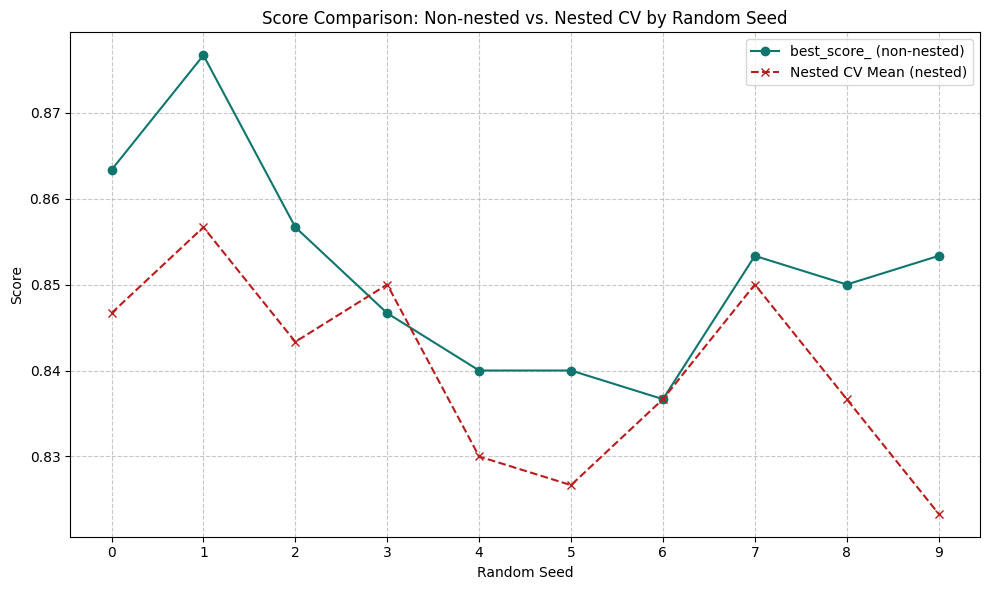


Average optimism (non-nested best_score_ - Nested CV): 0.0117
Number of times Nested CV was lower than non-nested best_score_: 8 of 10


In [ ]:
nao_aninhado, aninhado = [], []
for s in range(10):
    # Configures StratifiedKFold with the current seed
    i_cv = StratifiedKFold(5, shuffle=True, random_state=s)
    o_cv = StratifiedKFold(5, shuffle=True, random_state=s)

    # Performs the non-nested grid search
    g = GridSearchCV(novo_pipe(), GRADE, cv=i_cv)
    g.fit(X, y)
    nao_aninhado.append(g.best_score_)

    # Calculates the Nested CV score using cross_val_score with GridSearchCV
    nested_score = cross_val_score(g, X, y, cv=o_cv).mean()
    aninhado.append(nested_score)
    print(f"seed {s}: best_score_ = {g.best_score_:.4f} | nested = {nested_score:.4f}")

# Graph to compare the scores
plt.figure(figsize=(10, 6))
plt.plot(range(10), nao_aninhado, label='best_score_ (non-nested)', marker='o', linestyle='-', color=TEAL)
plt.plot(range(10), aninhado, label='Nested CV Mean (nested)', marker='x', linestyle='--', color=VERM)
plt.xlabel('Random Seed')
plt.ylabel('Score')
plt.title('Score Comparison: Non-nested vs. Nested CV by Random Seed')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(10)) # Ensures all seed ticks appear
plt.tight_layout() # Adjusts layout to prevent overlap
plt.show()

# Reporting optimism
nao_aninhado_arr = np.array(nao_aninhado)
aninhado_arr = np.array(aninhado)

otimismo = nao_aninhado_arr - aninhado_arr
otimismo_medio = np.mean(otimismo)
nested_menor_count = np.sum(aninhado_arr < nao_aninhado_arr)

print(f"\nAverage optimism (non-nested best_score_ - Nested CV): {otimismo_medio:.4f}")
print(f"Number of times Nested CV was lower than non-nested best_score_: {nested_menor_count} of 10")

*Your answer:*

With the results:

We observed the `best_score_` (non-nested) and Nested CV means for each of the 10 random seeds. The graph visually illustrates the difference between these two metrics.

*   **Average optimism (non-nested best_score_ - Nested CV):** `0.0117`
*   **Number of times Nested CV was lower than non-nested best_score_:** `8` out of 10

As expected, the `best_score_` (non-nested) consistently reports higher performance than the Nested CV mean. This demonstrates the `optimism` of `best_score_`, which is a direct consequence of the "winner's curse", where the maximum of several attempts (the 9 hyperparameter combinations in the grid search) tends to be inflated by sampling luck.

Nested CV, on the other hand, provides a more realistic and less optimistic estimate of the model's expected performance on unseen data, validating not only the hyperparameters but the *process* of hyperparameter selection. Most of the time (`8` out of 10), the Nested CV score was lower than the non-nested `best_score_`, confirming its ability to provide a more robust performance evaluation.

## Exercise 9 — Why a separate test is not enough

The most common approach — separating 30% for testing, searching in the rest, measuring once — also respects the golden rule. The problem is another: the number depends on the **split**. Repeat this approach with 10 different `train_test_split` seeds and store the 10 test scores. Plot them along with the Nested CV range (mean ± standard deviation from Exercise 4) and compare the **amplitude** (maximum − minimum) with the Nested CV's standard deviation.

**Example before starting.** A single hold-out, with seed 0: separates 30%, searches in the training set, measures once on the test set. This is the flow you will use in the next lecture, when grid search is the main topic.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
g = GridSearchCV(novo_pipe(), GRADE, cv=5).fit(X_tr, y_tr)
print("chosen:", g.best_params_)
print(f"best_score_ (validation): {g.best_score_:.4f}")
print(f"held-out TEST, 1 time  : {g.score(X_te, y_te):.4f}")

chosen: {'svc__C': 10, 'svc__gamma': 0.1}
best_score_ (validation): 0.8714
held-out TEST, 1 time  : 0.8000


**Now it's your turn.**

Seed 0: Score on TEST (separated) = 0.8444
Seed 1: Score on TEST (separated) = 0.7889
Seed 2: Score on TEST (separated) = 0.7889
Seed 3: Score on TEST (separated) = 0.8889
Seed 4: Score on TEST (separated) = 0.7667
Seed 5: Score on TEST (separated) = 0.7889
Seed 6: Score on TEST (separated) = 0.8444
Seed 7: Score on TEST (separated) = 0.7556
Seed 8: Score on TEST (separated) = 0.8667
Seed 9: Score on TEST (separated) = 0.7556


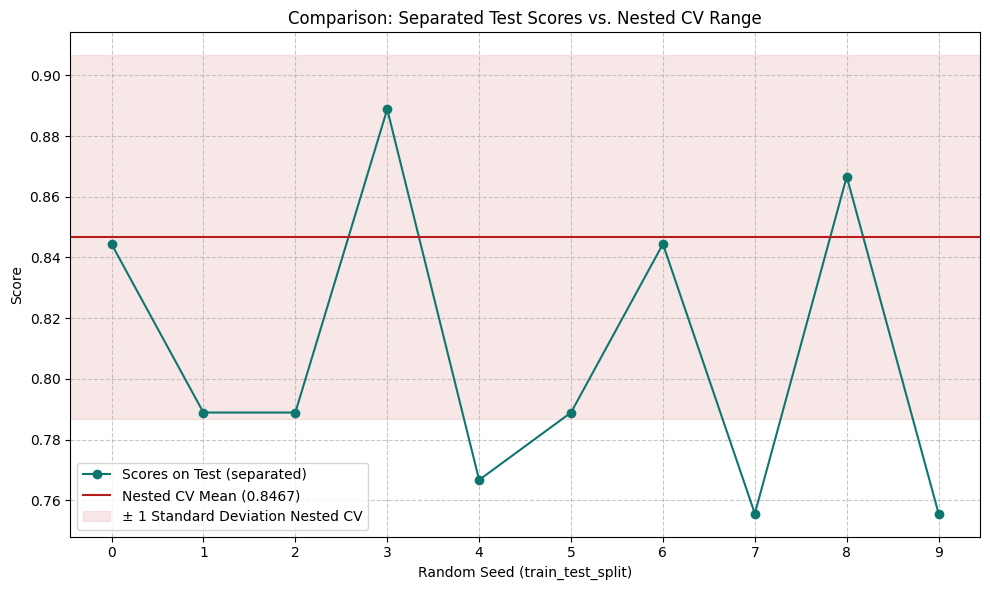


Amplitude of separated test scores (Max - Min): 0.1333
Standard deviation of Nested CV (Exercise 4): 0.0600


In [ ]:
testes = []
for s in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=s, stratify=y)
    g = GridSearchCV(novo_pipe(), GRADE, cv=interno) # Using 'interno' for consistency with previous exercises
    g.fit(X_tr, y_tr)
    score_teste = g.score(X_te, y_te)
    testes.append(score_teste)
    print(f"Seed {s}: Score on TEST (separated) = {score_teste:.4f}")

# Convert to array for easier calculations
testes_arr = np.array(testes)

# Get Nested CV metrics from Exercise 4
media_nested = notas.mean()
desvio_nested = notas.std()

# Calculate the amplitude of separated test scores
amplitude_testes = testes_arr.max() - testes_arr.min()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(10), testes_arr, label='Scores on Test (separated)', marker='o', linestyle='-', color=TEAL)
plt.axhline(media_nested, color=VERM, linestyle='-', label=f'Nested CV Mean ({media_nested:.4f})')
plt.axhspan(media_nested - desvio_nested, media_nested + desvio_nested, color=VERM, alpha=0.1, label='± 1 Standard Deviation Nested CV')

plt.xlabel('Random Seed (train_test_split)')
plt.ylabel('Score')
plt.title('Comparison: Separated Test Scores vs. Nested CV Range')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print(f"\nAmplitude of separated test scores (Max - Min): {amplitude_testes:.4f}")
print(f"Standard deviation of Nested CV (Exercise 4): {desvio_nested:.4f}")

With the results:

*   **Scores on Separated Test:** The 10 scores obtained on separate tests range between `0.7556` and `0.8889`.
*   **Amplitude of separated test scores (Max - Min):** `0.1333`
*   **Standard deviation of Nested CV (Exercise 4):** `0.0600`

The graph and numbers reveal that the `train_test_split` method (even with stratification) produces test scores that vary significantly from one random seed to another. The amplitude of the separated test scores (`0.1333`) is substantially larger than the standard deviation of the Nested CV mean (`0.0600`).

This illustrates the problem of relying on a single `train_test_split`: the reported performance can be highly sensitive to the specific data partition. Although it respects the "golden rule" (train and validate on separate data), the performance estimate is unstable. Nested CV, on the other hand, offers a more robust estimate with lower variability, as it averages results from several partitions, providing a more reliable view of expected performance on unseen data.

## Exercise 10 — The number and the model

Close the loop. Nested CV has already given you the **number**; it does not give the **model**. Run a single search on the **entire** dataset to obtain the combination that will go into production, and print the two things side by side: what you announce and what you deliver.

**Example before starting.** The final search is nothing special — it's the same `GridSearchCV` from Exercise 2, run on all data. What changes is its role: here it doesn't measure anything, it just chooses.

In [ ]:
final = GridSearchCV(novo_pipe(), GRADE, cv=interno).fit(X, y)
print("best_params_ :", final.best_params_)
print("best_estimator_ comes trained:", final.best_estimator_.named_steps["svc"])

best_params_ : {'svc__C': 1, 'svc__gamma': 0.1}
best_estimator_ comes trained: SVC(C=1, gamma=0.1)


**Now it's your turn.**

In [ ]:
final = GridSearchCV(novo_pipe(), GRADE, cv=interno).fit(X, y)

print(f"ANNOUNCE (Nested CV): {media_nested:.4f}")
print(f"DELIVER (best_score_ from final search): {final.best_score_:.4f}")
print(f"Best parameters for the final model: {final.best_params_}")

ANNOUNCE (Nested CV): 0.8467
DELIVER (best_score_ from final search): 0.8633
Best parameters for the final model: {'svc__C': 1, 'svc__gamma': 0.1}


With the results:

*   **ANNOUNCE (Nested CV):** `0.8467`
*   **DELIVER (best_score_ from final search):** `0.8633`
*   **Best parameters for the final model:** `{'svc__C': 1, 'svc__gamma': 0.1}`

In this last exercise, the `Nested CV` (`0.8467`) gave us the most realistic and reliable number for what performance we can **expect** when we put our model into production. It's our performance estimate on data the model has never seen.

On the other hand, the `best_score_` from the final search (`0.8633`) is the performance of the best hyperparameter combination found using *all* our training and (internal) validation data. This is the model we actually **deliver**, as it was trained with the maximum available information. It tends to be slightly higher than the Nested CV estimate, due to the inherent optimism of the "winner's curse" and having been trained on more data.

The `Nested CV` gives us **confidence** in the performance number, and the final `GridSearchCV` gives us the **model** to use.

---
## Conclusion

In one sentence: **who chooses does not measure**.

| | what it does | what it returns |
|---|---|---|
| `GridSearchCV` | sweeps the grid with CV within the training set | `best_params_`, `best_estimator_` — **the model** |
| `cross_val_score(GridSearchCV(...))` | repeats the entire search in K external folds | K scores → mean ± std dev — **the number** |

The `best_score_` is neither of these: it's the maximum of N attempts in validation, and Exercise 1 showed that this maximum increases with N. It serves to **choose**, never to report.

**When each is sufficient.** If you have a large dataset and a separate test set that no one has ever touched, the search + a single measurement on the test set is enough — and at one-fifth the cost (Exercise 5). Nested CV wins when the dataset is small, when reserving a fixed test set hurts, or when that test set has been looked at before and is no longer impartial.

**In the next lecture**, grid search becomes the main topic: how to choose grid values, combinatorial cost, the right `scoring` and what to do when the grid explodes. What you've established here — *who chooses does not measure* — is the rule that will apply there too.